## Actividad 3_15: Uso de KMeans para clasificación de clientes
<div style="border-style:groove;border-width:thin;padding:10px">
En este ejercicio vamos a utilizar KMeans para segmetar o clasificar a un grupo de clientes. En este caso se trata de los clientes de una empresa que vende una gran variedad de cosas. Vamos a utilizar un dataset de una campaña de márketing de una empresa que contiene datos de sus clientes. Estos datos son muy variados. Van desde la fecha de nacimiento hasta lo que han gastado en fruta pasando por el estado civil. 
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
1. Cargamos el dataset.
</div>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("marketing_campaign.csv",sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


<div style="border-style:groove;border-width:thin;padding:10px">
2. Borra la columna ID, ya que no nos aporta nada para segmentar los clientes. Cambia la Columna 'Year_Birth' por una con la edad de cada cliente. Pinta un gráfico de la distribución de edad. Puedes usar sns.violinplot para hacerlo. Consulta la documentación. Es una herramienta sencilla para pintar la distribución de una población por edad.
</div>

<Axes: xlabel='edad'>

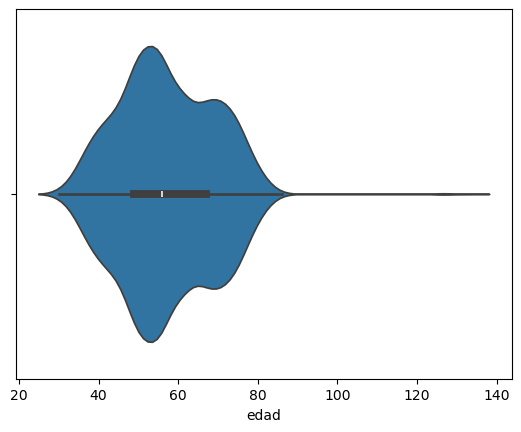

In [38]:
df.drop(columns=["ID"], inplace=True)
df["edad"] = 2026 - df["Year_Birth"]
df.drop(columns=["Year_Birth"], inplace=True)

# Mostrar la distribucion de edades
sns.violinplot(x=df["edad"])

<div style="border-style:groove;border-width:thin;padding:10px">
3. ¿Ves algo raro en la distribución? Elimina los datos que consideres que deben ser eliminados y vuelve a pintar la distribución por edad.
</div>

In [39]:
# Hay datos de clientes hasta 135 años, lo cual es imposible
df[df["edad"] < 90]

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,edad
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,0,0,0,0,0,0,3,11,1,69
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,0,0,0,0,0,0,3,11,0,72
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,0,0,0,0,0,0,3,11,0,61
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,0,0,0,0,0,0,3,11,0,42
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,0,0,0,0,0,0,3,11,0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,...,0,0,0,0,0,0,3,11,0,59
2236,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,...,0,0,0,1,0,0,3,11,0,80
2237,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,...,0,1,0,0,0,0,3,11,0,45
2238,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,...,0,0,0,0,0,0,3,11,0,70


<div style="border-style:groove;border-width:thin;padding:10px">
4. Pinta un gráfico de barras (sns.barplot) con el número de individuos por nivel educativo. Puedes usar también  df.Education.value_counts().
</div>

<Axes: xlabel='Education', ylabel='Income'>

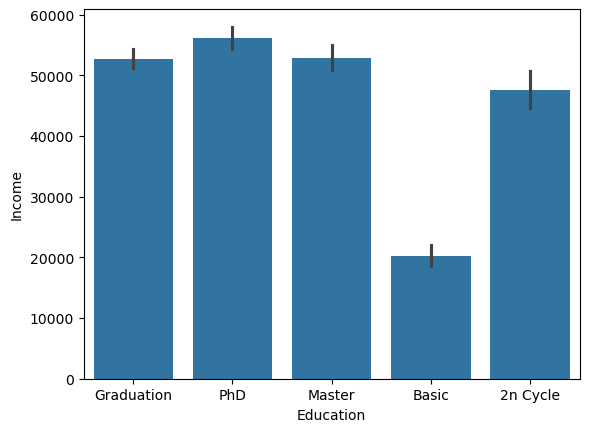

In [40]:
sns.barplot(x=df["Education"], y=df["Income"])

<div style="border-style:groove;border-width:thin;padding:10px">
5. Pinta ahora un gráfico de barras del sueldo medio por nivel educativo.
</div>

<Axes: xlabel='Education', ylabel='Income'>

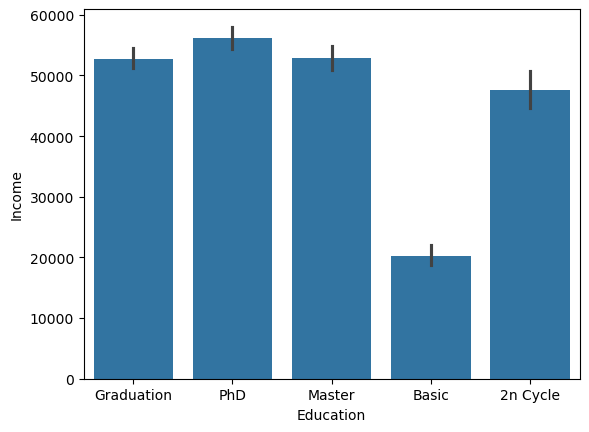

In [41]:
sns.barplot(x=df["Education"], y=df["Income"], estimator=np.mean)

<div style="border-style:groove;border-width:thin;padding:10px">
6. Pinta un gráfico de barras del sueldo por tramos de edades de 20 en 20 años.
</div>

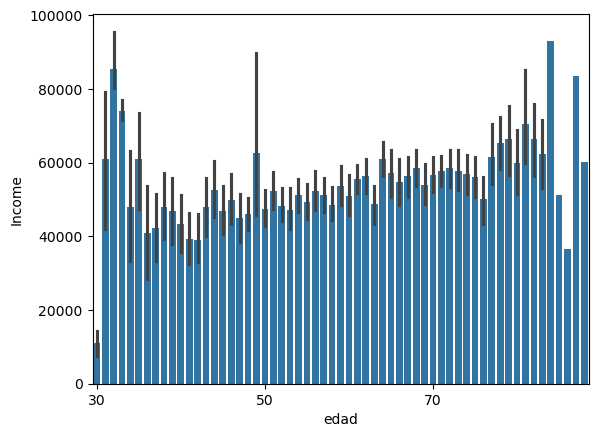

In [42]:
# Incrementando los tramos de 20 en 20 años
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

ax = sns.barplot(x=df["edad"], y=df["Income"])
ax.xaxis.set_major_locator(MultipleLocator(20))

<div style="border-style:groove;border-width:thin;padding:10px">
7. Cambia las columnas categóricas por valores numéricos (con el método que prefieras) y elimina los valores nulos (recuerda que se hace con dropna).
</div>

In [46]:
# Cambiando las columnas categoricas por valores numericos
df["Education"].unique()
df["Education"].replace({"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3, "2n Cycle": 4}, inplace=True)

df["Marital_Status"].unique()
df["Marital_Status"].replace({"Single": 0, "Married": 1, "Together": 2, "Divorced": 3, "Widow": 4, "Alone": 5, "Absurd": 6, "YOLO": 7}, inplace=True)

# Eliminando valores nulos
df.dropna(inplace=True)

/tmp/ipykernel_35631/2443081248.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Education"].replace({"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3, "2n Cycle": 4}, inplace=True)
/tmp/ipykernel_35631/2443081248.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Education"].replace({

<div style="border-style:groove;border-width:thin;padding:10px">
    <p>Ahora vamos a implementar el <b>METODO DEL CODO</b>. Este método consiste en hacer el método KMeans con distintos números de clusters (k). Después se calcula la suma de los Errores Cuadráticos Medios en cada Cluster (WCSS). Se pinta la gráfica de los WCSS para cada valor de k y te quedas con el valor del "codo", es decir, a partir del cual el WCSS baja bastante despacio.</p>
    <p>Los pasos serían los siguientes:</p>
    <ol>
        <li>Realiza el KMeans con valores de k de 0 a 10 o 15, por ejemplo.</li>
        <li>Guarda el dato kmeans.inertia_ para cada valor de k en una lista (este valor se corresponde con el WCSS)</li>
        <li>Pinta la lista de WCSS vs k.</li>
        <li>Busca el valor adecuado del "codo".</li>
    </ol>
</div>

In [47]:
X = df.drop(columns=["Income"])
y = df["Income"]

In [48]:
# Vamos a hacer KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
y_pred = kmeans.fit_predict(X)

ValueError: could not convert string to float: '04-09-2012'

<div style="border-style:groove;border-width:thin;padding:10px">
    <p>8. Implementa el método del codo con el dataset actual y anota el valor adecuado de k.</p>
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
9. Ahora implementa KMeans con el número obtenido anteriomente y guarda las etiquetas en una columna nueva del dataframe.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
10. Crea un dataframe nuevo con los datos del original pero quédate solo con las columnas que tienen valores significativos para nosotros. Vamos a ver si encontramos relaciones entre los clientes de un cluster (el 0, por ejemplo). Pinta los valores del dataframe (por ejemplo, el nivel educativo, el estado civil, los ingresos, el número total de hijos, el número total de gasto y la edad) de los individuos de la clase 0. ¿Identificas alguna relación?
</div>